Using device: cuda


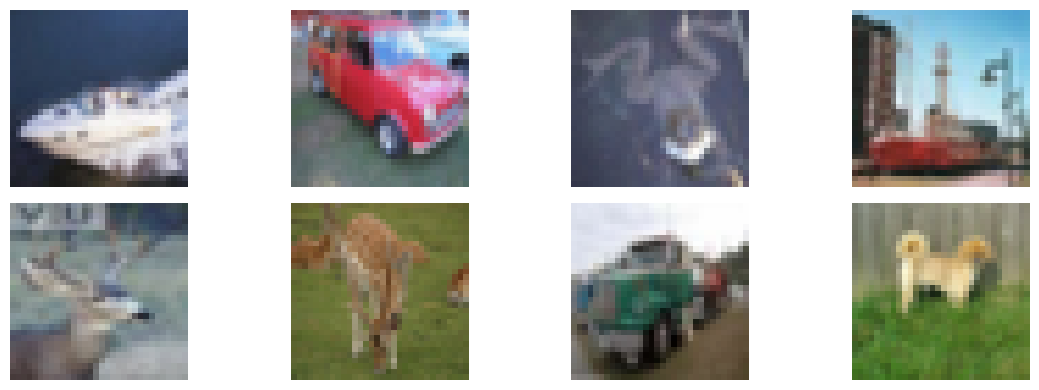

In [8]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# ---- 1. Data Preparation with Uniform Dequantization ----
def uniform_dequantize(x):
    u = torch.rand_like(x)
    x_deq = (x * 255.0 + u) / 256.0  # x in [0,1]; make [0,255] + U[0,1] then /256
    return x_deq

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(uniform_dequantize)
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Display a few training images
plt.figure(figsize=(12, 4))
for i in range(8):
    # Get a batch of images
    images, _ = next(iter(train_loader))
    
    # Select first image from batch
    img = images[0]
    
    # Create subplot
    plt.subplot(2, 4, i+1)
    
    # Convert from CHW to HWC format and display
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.axis('off')

plt.tight_layout()
plt.show()



In [ ]:
# ---- 2. ActNorm Layer Implementation ----
class ActNorm(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        # Initialize logs and bias as parameters
        self.logs = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.initialized = False
        
    def initialize(self, x):
        """Data dependent initialization"""
        print(f"Initializing ActNorm for {x.shape}")
            
        if not self.training:
            return
        
        with torch.no_grad():
            # Calculate mean and std across [0,2,3] dims (batch, height, width)
            mean = x.mean(dim=[0, 2, 3], keepdim=True)
            std = x.std(dim=[0, 2, 3], keepdim=True)
            
            # Add numerical stability
            std = torch.clamp(std, min=1e-6)  # Prevent division by zero
            
            # Initialize bias and logs
            self.bias.copy_(mean)
            
            self.logs.copy_(torch.log(1.0 / std))
            
            # Clamp logs to prevent extreme values
            self.logs.data.clamp_(-10, 10)
            
            # Only print details for first initialization to reduce spam
            if self._init_count == 1:
                print(f"ActNorm init - mean: {mean.flatten()[:3]}, std: {std.flatten()[:3]}")
                print(f"ActNorm init - bias: {self.bias.flatten()[:3]}, logs: {self.logs.flatten()[:3]}")
            
        self.initialized = True
            
    def forward(self, x, reverse=False):
        if not self.initialized:
            self.initialize(x)
            
        if reverse:
            # Inverse operation: y = (x - bias) / exp(logs)
            return (x - self.bias) * torch.exp(-self.logs)
        else:
            # Forward operation: y = (x + bias) * exp(logs)
            return (x + self.bias) * torch.exp(self.logs), self.log_det_jacobian(x)
            
    def log_det_jacobian(self, x):
        """Calculate log determinant of the Jacobian"""
        # For each spatial location, log_det is sum of logs across channels
        # Shape: batch_size
        batch_size = x.shape[0]
        height, width = x.shape[2], x.shape[3]
        return self.logs.sum() * height * width * torch.ones(batch_size, device=x.device)
    
    def inverse(self, x):
        return self.forward(x, reverse=True)


In [3]:
# ---- 3. Invertible 1x1 Convolution ----
class InvertibleConv1x1(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        # Initialize with QR decomposition for stability
        w = torch.randn(num_channels, num_channels)
        w = torch.linalg.qr(w)[0]  # QR decomposition
        self.w = nn.Parameter(w.unsqueeze(-1).unsqueeze(-1))  # Make it 4D for conv

    def forward(self, x, reverse=False):
        batch_size, channels, height, width = x.shape
        
        if not reverse:
            # Forward pass using 1x1 convolution
            y = torch.nn.functional.conv2d(x, self.w)
            
            # Log determinant: log|det(W)| * height * width for each sample in batch
            w_2d = self.w.squeeze(-1).squeeze(-1)  # Back to 2D for determinant
            
            # Add numerical stability check
            det_sign, log_det_w = torch.slogdet(w_2d)
            if det_sign <= 0:
                # Only warn occasionally to avoid spam
                if not hasattr(self, '_det_warning_count'):
                    self._det_warning_count = 0
                if self._det_warning_count < 3:
                    print(f"Warning: Non-positive determinant in Conv1x1: {det_sign}")
                    self._det_warning_count += 1
                log_det_w = torch.tensor(0.0, device=x.device)
            
            log_det = log_det_w * height * width * torch.ones(batch_size, device=x.device)
            
            return y, log_det
        else:
            # Inverse pass
            w_2d = self.w.squeeze(-1).squeeze(-1)
            try:
                w_inv = torch.linalg.inv(w_2d).unsqueeze(-1).unsqueeze(-1)
            except RuntimeError:
                # Only warn occasionally to avoid spam
                if not hasattr(self, '_inv_warning_count'):
                    self._inv_warning_count = 0
                if self._inv_warning_count < 3:
                    print("Warning: Matrix inversion failed in Conv1x1, using pseudo-inverse")
                    self._inv_warning_count += 1
                w_inv = torch.linalg.pinv(w_2d).unsqueeze(-1).unsqueeze(-1)
            return torch.nn.functional.conv2d(x, w_inv)


In [4]:
# ---- 4. Affine Coupling Layer ----
class AffineCoupling(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        
        # ActNorm, 1x1 conv, and neural network for each coupling layer
        self.actnorm = ActNorm(in_channels)
        self.conv1x1 = InvertibleConv1x1(in_channels)
        
        # Neural network that predicts scale and translation factors
        self.nn = nn.Sequential(
            nn.Conv2d(in_channels // 2, hidden_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, in_channels, 3, padding=1),
        )
        
        # Initialize last layer to zeros for stability
        self.nn[-1].weight.data.zero_()
        self.nn[-1].bias.data.zero_()
        
    def forward(self, x, reverse=False):
        total_log_det = 0
        
        if not reverse:
            # Forward pass
            # ActNorm
            x, log_det1 = self.actnorm(x)
            total_log_det = total_log_det + log_det1
            
            # 1x1 conv
            x, log_det2 = self.conv1x1(x)
            total_log_det = total_log_det + log_det2
            
            # Affine coupling
            # Split input into two halves along channel dimension
            x1, x2 = x.chunk(2, dim=1)
            
            # Get scale and translation factors from neural network
            nn_out = self.nn(x1)
            log_s, t = nn_out.chunk(2, dim=1)
            
            # More stable scale calculation
            # Clamp log_s to prevent extreme values
            log_s = torch.clamp(log_s, -10, 10)
            s = torch.exp(log_s)  # Use exp instead of sigmoid for better numerical properties
            s = torch.clamp(s, min=0.01, max=100)  # Prevent extreme scaling
            
            # Forward operation
            z1 = x1
            z2 = (x2 + t) * s
            
            # Concatenate back along channel dimension
            z = torch.cat([z1, z2], dim=1)
            
            # Add coupling log determinant with numerical stability
            coupling_log_det = torch.sum(log_s.view(log_s.shape[0], -1), dim=1)
            total_log_det = total_log_det + coupling_log_det
            
            return z, total_log_det
            
        else:
            # Inverse pass
            # First inverse the coupling
            x1, x2 = x.chunk(2, dim=1)
            nn_out = self.nn(x1)
            log_s, t = nn_out.chunk(2, dim=1)
            
            # Use same stable calculation as forward pass
            log_s = torch.clamp(log_s, -10, 10)
            s = torch.exp(log_s)
            s = torch.clamp(s, min=0.01, max=100)
            
            z2 = (x2 / s) - t
            z1 = x1
            x = torch.cat([z1, z2], dim=1)
            
            # Inverse 1x1 conv
            x = self.conv1x1(x, reverse=True)
            
            # Inverse ActNorm
            x = self.actnorm(x, reverse=True)
            
            return x
            
    def inverse(self, x):
        return self.forward(x, reverse=True)


In [5]:
# ---- 5. Glow Model ----
class Glow(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers, num_flow_layers):
        super().__init__()
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.num_layers = num_layers
        self.num_flow_layers = num_flow_layers
        
        self.flows = nn.ModuleList()
        current_channels = in_channels
        
        for i in range(num_layers):
            # After squeeze operation, channels are multiplied by 4
            squeeze_channels = current_channels * 4
            
            flow_layers = []
            # Apply flow steps to all channels (not split for flow steps)
            for _ in range(num_flow_layers):
                flow_layers.append(AffineCoupling(squeeze_channels, hidden_channels))
            
            self.flows.append(nn.ModuleList(flow_layers))
            
            # After split (if not last layer), channels are halved
            if i < num_layers - 1:
                current_channels = squeeze_channels // 2
            else:
                current_channels = squeeze_channels
    
    def forward(self, x, log_det=None, reverse=False):
        if log_det is None:
            log_det = torch.zeros(x.size(0), device=x.device)
            
        if reverse:
            # Reverse pass - generate samples from latent z
            return self._reverse_pass(x)
        else:
            # Forward pass - encode input to latent z
            return self._forward_pass(x, log_det)
    
    def _forward_pass(self, x, log_det):
        """Forward pass: input -> latent"""
        outputs = []
        
        for i in range(self.num_layers):
            # Squeeze: spatial dimensions -> channels
            b, c, h, w = x.shape
            x = x.reshape(b, c, h // 2, 2, w // 2, 2)
            x = x.permute(0, 1, 3, 5, 2, 4)
            x = x.reshape(b, c * 4, h // 2, w // 2)
            
            # Flow steps
            for flow in self.flows[i]:
                x, ld = flow(x)
                log_det = log_det + ld
            
            # Split and keep half the channels (except for last layer)
            if i < self.num_layers - 1:
                x, split = x.chunk(2, dim=1)
                outputs.append(split)
                
        return x, log_det
    
    def _reverse_pass(self, z):
        """Reverse pass: latent -> output"""
        # Store the splits that we'll need to reconstruct
        # For sampling, we'll generate these from noise as well
        batch_size = z.shape[0]
        device = z.device
        
        x = z
        
        for i in reversed(range(self.num_layers)):
            # Unsplit: add back the split channels (except for last layer)
            if i < self.num_layers - 1:
                # Generate split from noise with appropriate shape
                # The split should have half the channels of what we'll have after unsqueeze
                current_channels = x.shape[1]
                split_channels = current_channels
                h, w = x.shape[2], x.shape[3]
                
                split = torch.randn(batch_size, split_channels, h, w, device=device)
                x = torch.cat([x, split], dim=1)
            
            # Reverse flow steps
            for flow in reversed(self.flows[i]):
                x = flow.inverse(x)
            
            # Unsqueeze: channels -> spatial dimensions
            b, c, h, w = x.shape
            x = x.reshape(b, c // 4, 2, 2, h, w)
            x = x.permute(0, 1, 4, 2, 5, 3)
            x = x.reshape(b, c // 4, h * 2, w * 2)
                
        return x, torch.zeros(batch_size, device=device)  # Return dummy log_det for sampling


In [6]:
# ---- 6. Sampling Functions ----
def sample_from_model(model, num_samples=8, temperature=1.0, device='cpu'):
    """
    Sample images from the trained Glow model
    
    Args:
        model: Trained Glow model
        num_samples: Number of samples to generate
        temperature: Temperature for sampling (lower = more conservative)
        device: Device to run sampling on
    
    Returns:
        Generated samples as a tensor
    """
    model.eval()
    
    with torch.no_grad():
        # Get the final output shape by running a dummy forward pass
        dummy_input = torch.randn(1, 3, 32, 32).to(device)
        dummy_z, _ = model(dummy_input)
        z_shape = dummy_z.shape[1:]  # Remove batch dimension
        
        # Sample from standard normal distribution
        z = torch.randn(num_samples, *z_shape).to(device) * temperature
        
        # Generate samples by running the model in reverse
        try:
            samples, _ = model(z, reverse=True)
            
            # Clamp to valid range [0, 1]
            samples = torch.clamp(samples, 0, 1)
            
            return samples
            
        except Exception as e:
            print(f"Error during sampling: {e}")
            return None

def visualize_samples(samples, epoch, save_path=None):
    """
    Visualize generated samples
    """
    if samples is None:
        return
        
    # Convert to numpy and rearrange for plotting
    samples_np = samples.cpu().numpy()
    
    # Create subplot
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f'Generated Samples - Epoch {epoch}')
    
    for i in range(min(8, samples_np.shape[0])):
        row = i // 4
        col = i % 4
        
        # Transpose from CHW to HWC for matplotlib
        img = np.transpose(samples_np[i], (1, 2, 0))
        
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'Sample {i+1}')
    
    # Hide empty subplots
    for i in range(samples_np.shape[0], 8):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}/samples_epoch_{epoch}.png', dpi=150, bbox_inches='tight')
    
    plt.show()

print("Sampling functions ready!")


Sampling functions ready!


Data shape: torch.Size([16, 3, 32, 32])
Starting training with sampling...
Initializing ActNorm for torch.Size([16, 12, 16, 16])
ActNorm init - mean: tensor([0.5124, 0.5125, 0.5091], device='cuda:0'), std: tensor([0.2505, 0.2507, 0.2485], device='cuda:0')
ActNorm init - bias: tensor([0.5124, 0.5125, 0.5091], device='cuda:0', requires_grad=True), logs: tensor([1.3844, 1.3837, 1.3924], device='cuda:0', requires_grad=True)
Initializing ActNorm for torch.Size([16, 12, 16, 16])
ActNorm init - mean: tensor([ 1.0690,  5.0692, -1.2628], device='cuda:0'), std: tensor([0.4285, 1.2284, 0.4155], device='cuda:0')
ActNorm init - bias: tensor([ 1.0690,  5.0692, -1.2628], device='cuda:0', requires_grad=True), logs: tensor([ 0.8476, -0.2057,  0.8782], device='cuda:0', requires_grad=True)
Initializing ActNorm for torch.Size([16, 12, 16, 16])
ActNorm init - mean: tensor([-14.6326,  -0.0350,  11.8376], device='cuda:0'), std: tensor([1.7260, 0.9225, 1.4414], device='cuda:0')
ActNorm init - bias: tensor([-1

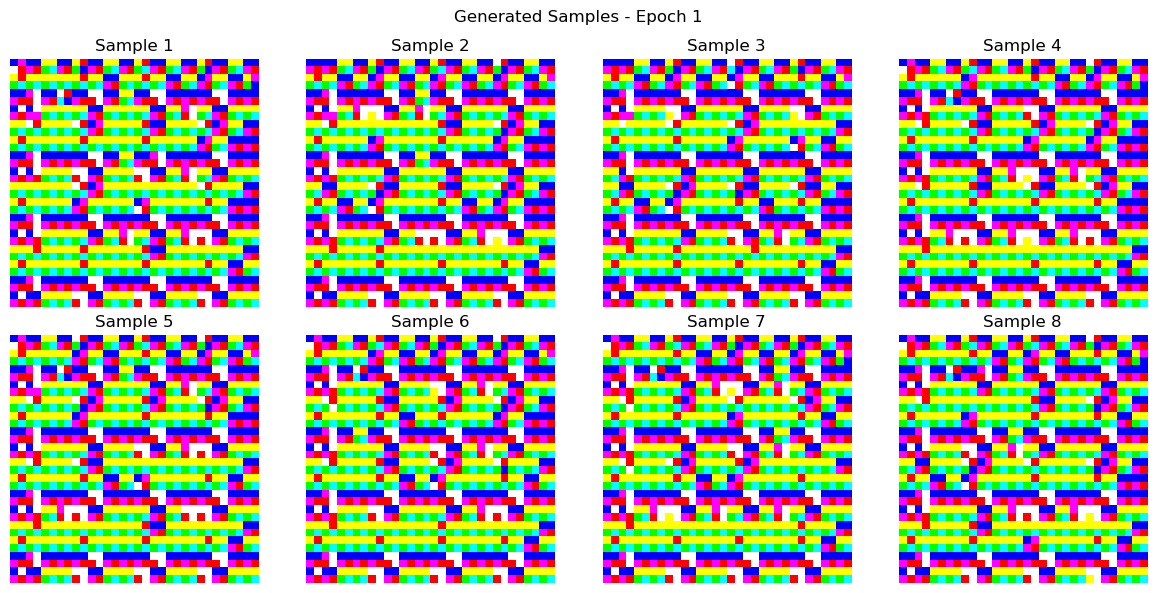

Epoch 2/15, Average Loss: 7340.3277
Generating samples...
Visualizing samples...


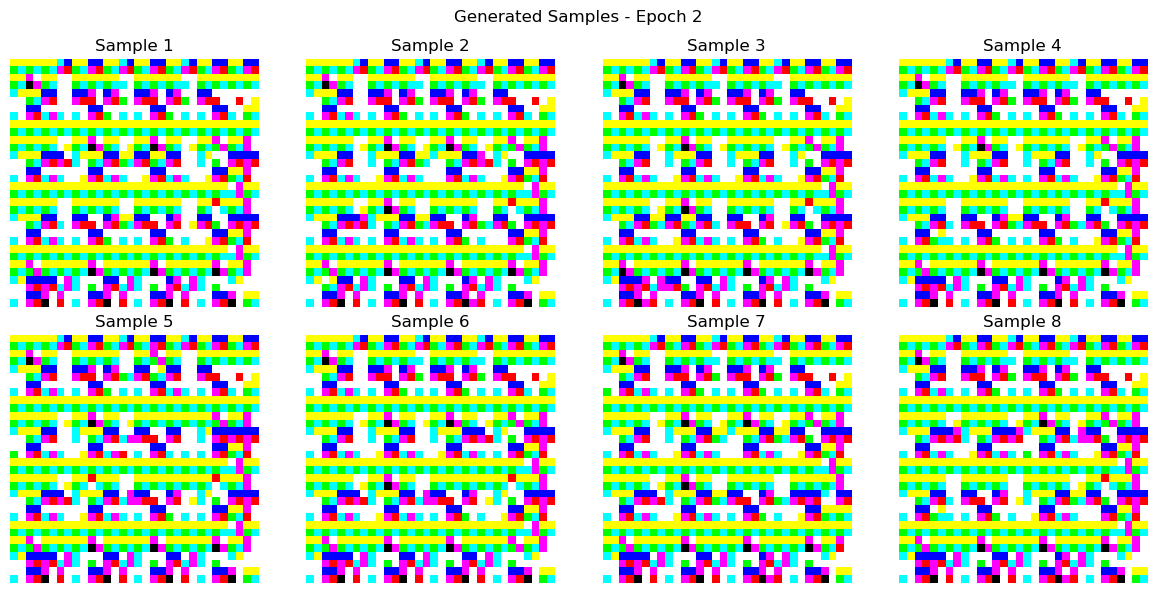

Epoch 3/15, Average Loss: 25071488.8582
Generating samples...
Visualizing samples...


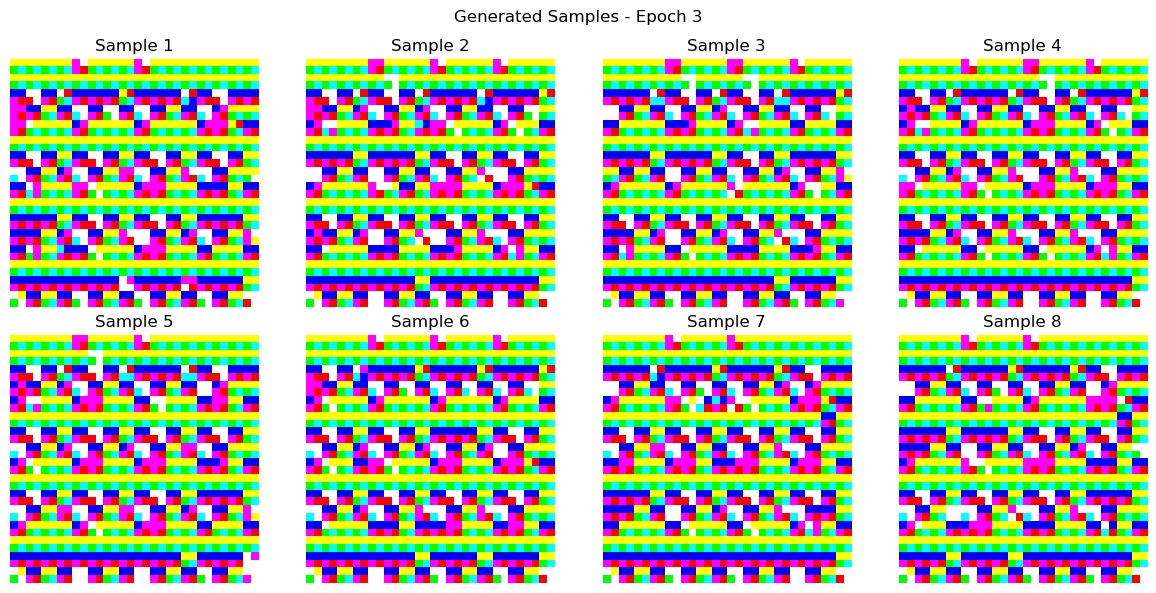

Epoch 4/15, Average Loss: -10723.8235
Generating samples...
Visualizing samples...


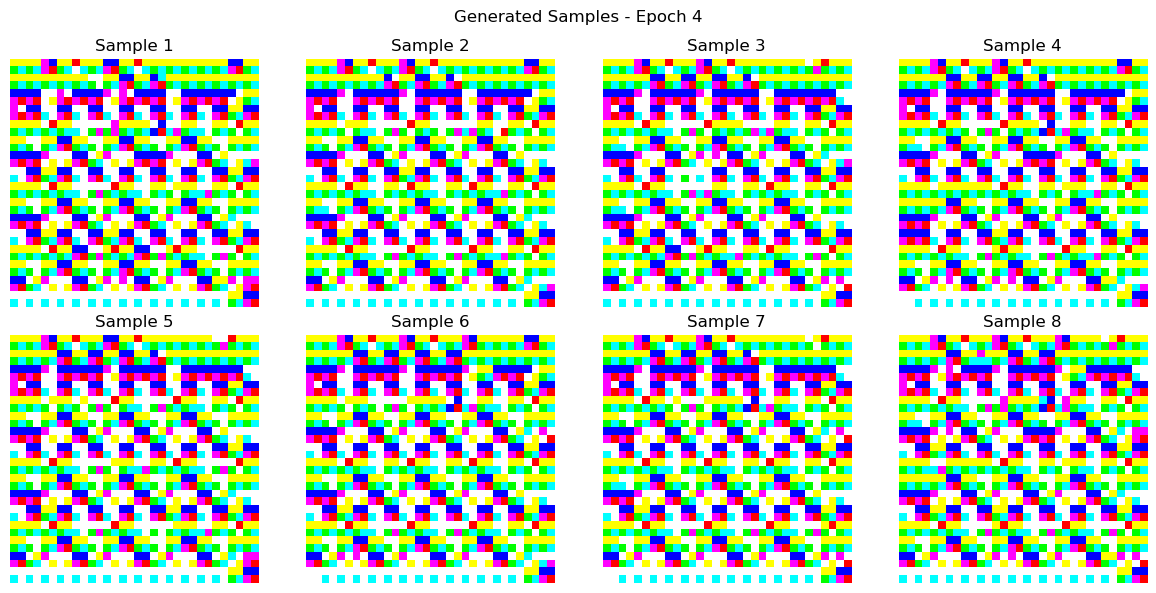

Epoch 5/15, Average Loss: -15805.2569
Generating samples...
Visualizing samples...


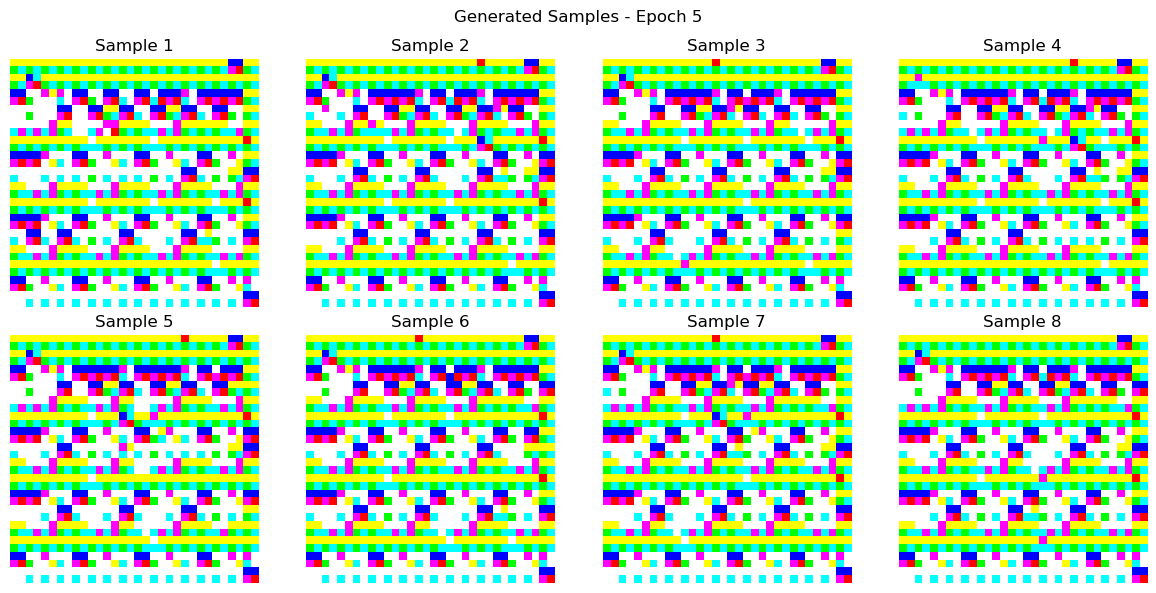

Epoch 6/15, Average Loss: -18637.7130
Generating samples...
Visualizing samples...


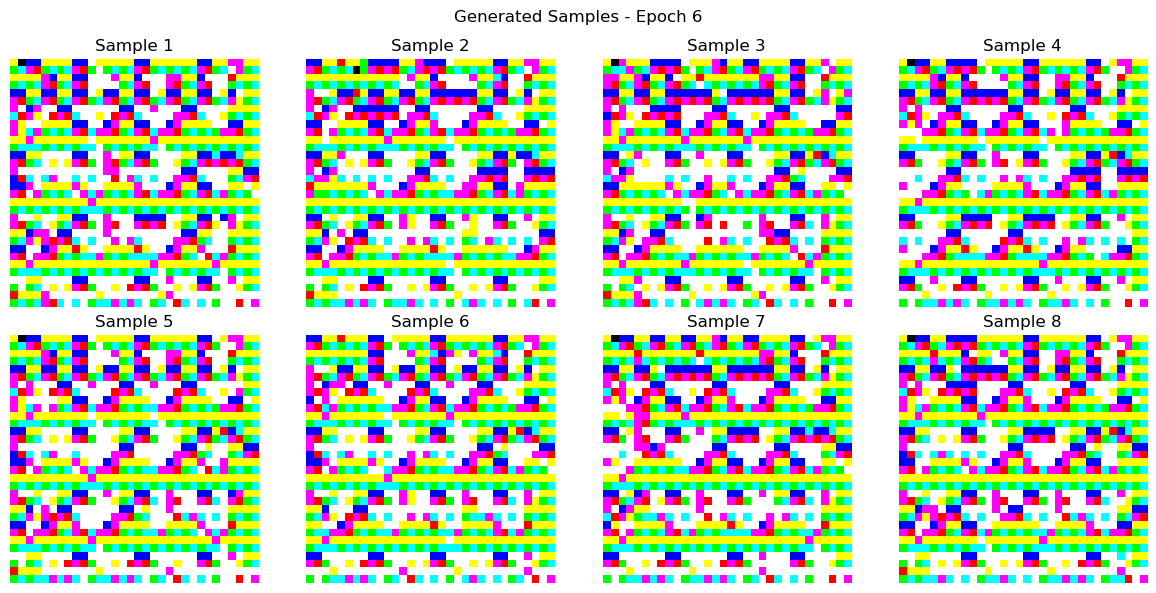

KeyboardInterrupt: 

In [7]:
# ---- 7. Enhanced Training Loop with Sampling ----
import torch.optim as optim
import os

# Create directory for saving samples
os.makedirs('glow_samples', exist_ok=True)

# First let's check the data shape
sample_batch = next(iter(train_loader))
print(f"Data shape: {sample_batch[0].shape}")

num_layers = 3  # Start with fewer layers for debugging
num_flow_layers = 4  # Start with fewer flow layers
hidden_channels = 256  # Start with smaller hidden channels
input_channels = 3  # CIFAR-10 has 3 color channels
input_dim = 32 * 32 * input_channels

model = Glow(in_channels=input_channels, hidden_channels=hidden_channels, num_layers=num_layers, num_flow_layers=num_flow_layers)
model = model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 15  # Train for a few epochs

print("Starting training with sampling...")
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    num_batches = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        x = data.to(device)
        
        z, log_det = model(x)
        
        # Check for NaN/inf values
        if torch.isnan(z).any() or torch.isnan(log_det).any():
            print(f"NaN detected in epoch {epoch}, batch {batch_idx}")
            break
        
        # Calculate loss
        log_prob = -0.5 * (z ** 2).sum(dim=[1, 2, 3]) - 0.5 * z.numel() / z.shape[0] * np.log(2 * np.pi)
        loss = -(log_prob + log_det).mean()
        
        if torch.isnan(loss):
            print(f"NaN loss in epoch {epoch}, batch {batch_idx}")
            break
            
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
        # # Only process a few batches for debugging
        # if batch_idx >= 4:
        #     break
    
    avg_loss = epoch_loss / num_batches if num_batches > 0 else float('inf')
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")
    
    # Sample from the model at the end of each epoch
    print("Generating samples...")
    samples = sample_from_model(model, num_samples=8, temperature=0.7, device=device)
    
    if samples is not None:
        print("Visualizing samples...")
        visualize_samples(samples, epoch+1, save_path='glow_samples')
    else:
        print("Failed to generate samples")
    
    # Set model back to training mode
    model.train()

print("Training completed!")
